# ❤️ Heart Failure Prediction Dataset

This dataset contains medical information about patients and is used to predict whether a person has heart disease based on various clinical features.

### Dataset Information
- **Rows:** 918
- **Columns:** 12
- **Target Variable:** `HeartDisease`
- **Problem Type:** Binary Classification

### Features
- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- MaxHR
- ExerciseAngina
- Oldpeak
- ST_Slope

### Target
- **0:** No Heart Disease
- **1:** Heart Disease

### Objective
The goal of this project is to build a machine learning model that predicts whether a patient has heart disease based on their medical attributes.

### Importing all necessary libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Loading dataset


In [2]:
df = pd.read_csv("data/heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

## Getting statistical info

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


## Checking missing and duplicate values 

In [7]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Observation: No missing values present in the dataset

In [8]:
df.duplicated().sum()

np.int64(0)

### Observation: No duplicate values found

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## Unique values

In [10]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [12]:
print("Unique values in column sex are:",end=" ")
print(list(df["Sex"].unique()))

print("Unique values in column ChestPainType are:",end=" ")
print(list(df["ChestPainType"].unique()))

print("Unique values in column FastingBS are:",end=" ")
print(list(df["FastingBS"].unique()))

print("Unique values in column RestingECG are:",end=" ")
print(list(df["RestingECG"].unique()))

print("Unique values in column ExerciseAngina are:",end=" ")
print(list(df["ExerciseAngina"].unique()))

print("Unique values in column ST_Slope are:",end=" ")
print(list(df["ST_Slope"].unique()))



Unique values in column sex are: ['M', 'F']
Unique values in column ChestPainType are: ['ATA', 'NAP', 'ASY', 'TA']
Unique values in column FastingBS are: [np.int64(0), np.int64(1)]
Unique values in column RestingECG are: ['Normal', 'ST', 'LVH']
Unique values in column ExerciseAngina are: ['N', 'Y']
Unique values in column ST_Slope are: ['Up', 'Flat', 'Down']


## Numerical and Categorical columns

In [13]:
num_features = [feature for feature in df.columns if df[feature].dtype!="str"]
cat_features = [feature for feature in df.columns if df[feature].dtype=="str"]

print(f"We have {len(num_features)} numerical features named {num_features}")
print(f"We have {len(cat_features)} categorical features named {cat_features}")

We have 7 numerical features named ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
We have 5 categorical features named ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## Visualising counts of heart disease 

In [14]:
counts = df["HeartDisease"].value_counts(normalize=True)*100 
counts

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

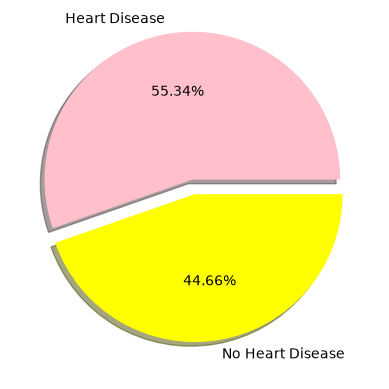

In [15]:
labels = ["Heart Disease","No Heart Disease"]
size = counts 
explode = [0.1,0]
color = ["pink","yellow"]
plt.pie(counts,explode=explode,colors=color,labels=labels,autopct="%1.2f%%",shadow=True)